# MICROPROJECT ADVANCED 1: End-to-End ML Pipeline
## Phase 1: Data Engineering & Exploration
**Objective:** To build a robust Fraud Detection Model using a real-world dataset.

In [24]:
# Importing essential libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the dataset
df = pd.read_csv('data.csv')

print("Libraries loaded and Data imported successfully!")
# Displaying the first 5 rows
df.head()

Libraries loaded and Data imported successfully!


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,'0'
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,'0'
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,'0'
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,'0'
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,'0'


# Section 2: Data Cleaning
In this section, we handle missing values and perform basic data sanity checks.

In [25]:
# Checking for missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Handling missing values (Filling with mean for numerical columns)
df = df.fillna(df.mean(numeric_only=True))

# Checking data types and info
print("\nDataset Info:")
print(df.info())

Missing values in each column:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 1

# Section 3: Exploratory Data Analysis (EDA)
Visualizing the distribution of classes and understanding feature correlations.

In [ ]:
# Checking the distribution of 'Class' (0: Normal, 1: Fraud)
print("Class Distribution:")
print(df['Class'].value_counts())

# Plotting the Class distribution
plt.figure(figsize=(7,5))
sns.countplot(x='Class', data=df)
plt.title('Distribution of Normal vs Fraud Transactions')
plt.show()

# Plotting Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title('Feature Correlation Matrix')
plt.show()

# Section 4: Data Splitting & Scaling
Preparing the data for Model Training by splitting it into Train and Test sets.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Defining Features (X) and Target (y)
X = df.drop('Class', axis=1)
y = df['Class']

# Splitting the data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scaling the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data Splitting and Scaling Complete!")

# Section 5: Model Development & Comparison
In this phase, we train three different Machine Learning models and compare their performance using metrics like Accuracy, Precision, and Recall.

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Initialize and train the model
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test)

print("--- Logistic Regression Results ---")
print(classification_report(y_test, y_pred_lr))

--- Logistic Regression Results ---
              precision    recall  f1-score   support

         '0'       1.00      1.00      1.00     56864
         '1'       0.83      0.63      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



In [29]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

print("--- Random Forest Results ---")
print(classification_report(y_test, y_pred_rf))

--- Random Forest Results ---
              precision    recall  f1-score   support

         '0'       1.00      1.00      1.00     56864
         '1'       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



In [30]:
from sklearn.svm import LinearSVC

# Initialize and train the model
svm_model = LinearSVC(max_iter=1000)
svm_model.fit(X_train, y_train)

# Predictions
y_pred_svm = svm_model.predict(X_test)

print("--- SVM Results ---")
print(classification_report(y_test, y_pred_svm))

--- SVM Results ---
              precision    recall  f1-score   support

         '0'       1.00      1.00      1.00     56864
         '1'       0.83      0.59      0.69        98

    accuracy                           1.00     56962
   macro avg       0.91      0.80      0.85     56962
weighted avg       1.00      1.00      1.00     56962



# Section 6: Model Evaluation
Visualizing the Confusion Matrix to see how many Fraud cases were correctly identified.

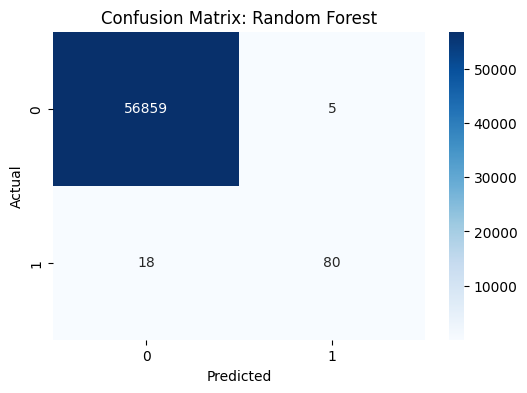

In [31]:
# Function to plot Confusion Matrix
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

# Plotting for Random Forest (usually the best performer)
plot_confusion_matrix(y_test, y_pred_rf, "Confusion Matrix: Random Forest")

# Section 7: Hyperparameter Tuning
Optimizing the Random Forest model using RandomizedSearchCV to find the best parameters for fraud detection.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Defining parameters to test
param_dist = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# Running RandomizedSearch
random_search = RandomizedSearchCV(estimator=rf_model, param_distributions=param_dist, n_iter=3, cv=3)
random_search.fit(X_train, y_train)

print("Best Parameters Found:", random_search.best_params_)
final_model = random_search.best_estimator_

# Section 8: Feature Importance
Analyzing which features contribute most to the model's decision-making process.

In [ ]:
# Plotting Top 10 Features
importances = final_model.feature_importances_
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(10,6))
plt.title('Top 10 Important Features')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [df.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

# Section 9: Model Serialization
Saving the trained model using Joblib for production deployment.

In [ ]:
import joblib
import os

# Creating a directory for the model if it doesn't exist
if not os.path.exists('models'):
    os.makedirs('models')

# Saving the final model and the scaler
joblib.dump(final_model, 'models/fraud_detection_model.joblib')
joblib.dump(scaler, 'models/scaler.joblib')

print("Model and Scaler saved successfully in 'models/' folder!")